In [2]:
# Load dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Loaded:", filename)
display(df.head())


Saving train.csv to train.csv
Loaded: train.csv


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [3]:
target_column = "is_claim"
y = df[target_column]

drop_cols = ["policy_id"] if "policy_id" in df.columns else []
X = df.drop(columns=[target_column] + drop_cols)

# Feature Engineering (same as your notebook)
if {"policy_tenure", "age_of_policyholder"} <= set(df.columns):
    X["tenure_to_age"] = df["policy_tenure"] / (df["age_of_policyholder"] + 1e-6)

if "age_of_car" in df.columns:
    X["car_age_bucket"] = pd.cut(X["age_of_car"], [-0.01,0.02,0.05,0.1,1.0], labels=False)

if "population_density" in df.columns:
    X["log_population_density"] = np.log1p(X["population_density"])

if {"annual_premium","policy_tenure"} <= set(df.columns):
    X["premium_risk"] = X["annual_premium"] / (X["policy_tenure"]+1)

# One-hot encode
categorical_cols = X.select_dtypes(include=["object","category"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [4]:
from sklearn.model_selection import train_test_split

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train_all, y_train)

print("Post SMOTE-ENN class balance:")
print(y_train_bal.value_counts())


Post SMOTE-ENN class balance:
is_claim
1    29671
0    26331
Name: count, dtype: int64


In [6]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_bal, y_train_bal)
mi_series = pd.Series(mi_scores, index=X_train_bal.columns).sort_values(ascending=False)

# TWO MI-based subsets
top10_features = mi_series.head(10).index.tolist()
top20_features = mi_series.head(20).index.tolist()

X_train_mi10 = X_train_bal[top10_features]
X_test_mi10  = X_test_all[top10_features]

X_train_mi20 = X_train_bal[top20_features]
X_test_mi20  = X_test_all[top20_features]


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_all = StandardScaler()
scaler_mi10 = StandardScaler()
scaler_mi20 = StandardScaler()

X_train_all_scaled = scaler_all.fit_transform(X_train_bal)
X_test_all_scaled  = scaler_all.transform(X_test_all)

X_train_mi10_scaled = scaler_mi10.fit_transform(X_train_mi10)
X_test_mi10_scaled  = scaler_mi10.transform(X_test_mi10)

X_train_mi20_scaled = scaler_mi20.fit_transform(X_train_mi20)
X_test_mi20_scaled  = scaler_mi20.transform(X_test_mi20)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [ ]:
from sklearn.model_selection import GridSearchCV

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42),
    param_grid={
        "n_estimators": [100,200, 400],
        "max_depth": [10, 18, 25]
    },
    scoring="f1",
    cv=3,
    n_jobs=-1
)
rf_grid.fit(X_train_bal, y_train_bal)
best_rf = rf_grid.best_estimator_

# Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid={
        "max_depth": [8, 10, 12],
        "min_samples_split": [2, 4, 6]
    },
    scoring="f1",
    cv=3
)
dt_grid.fit(X_train_bal, y_train_bal)
best_dt = dt_grid.best_estimator_

# XGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, tree_method="hist"),
    param_grid={
        "learning_rate": [0.05, 0.01,0.1],
        "max_depth": [4, 6,10],
        "n_estimators": [100, 200, 400]
    },
    scoring="f1",
    cv=3
)
xgb_grid.fit(X_train_bal, y_train_bal)
best_xgb = xgb_grid.best_estimator_


In [10]:
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.1, 0.9, 41)
    best_f1 = -1
    best_thr = 0.5

    for thr in thresholds:
        preds = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

models = {
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": best_xgb,
    "SVM": SVC(probability=True)
}

results = []

def evaluate_subset(model_name, model, X_train, X_test, subset_name):
    model.fit(X_train, y_train_bal)
    y_prob = model.predict_proba(X_test)[:, 1]
    thr, f1 = find_best_threshold(y_test, y_prob)
    y_pred = (y_prob >= thr).astype(int)

    results.append({
        "Subset": subset_name,
        "Model": model_name,
        "Best Threshold": thr,
        "F1 Score": f1,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

# Evaluate all subsets
for name, model in models.items():
    evaluate_subset(name, model, X_train_all_scaled, X_test_all_scaled, "All Features")
    evaluate_subset(name, model, X_train_mi10_scaled, X_test_mi10_scaled, "MI Top 10")
    evaluate_subset(name, model, X_train_mi20_scaled, X_test_mi20_scaled, "MI Top 20")

df_results = pd.DataFrame(results)
display(df_results)


,Subset,Model,Best Threshold,F1 Score,Accuracy,Precision,Recall
0,All Features,Random Forest,0.36,0.151336,0.644936,0.089333,0.494667
1,MI Top 10,Random Forest,0.42,0.155320,0.714139,0.095771,0.410667
2,MI Top 20,Random Forest,0.28,0.149164,0.613534,0.086814,0.529333
3,All Features,Decision Tree,0.66,0.151728,0.763376,0.098452,0.330667
4,MI Top 10,Decision Tree,0.50,0.152514,0.657650,0.090612,0.481333
5,MI Top 20,Decision Tree,0.56,0.147173,0.756720,0.094871,0.328000
6,All Features,LDA,0.58,0.137635,0.639645,0.081264,0.449333
7,MI Top 10,LDA,0.66,0.143107,0.749637,0.091623,0.326667
8,MI Top 20,LDA,0.56,0.138379,0.603635,0.080371,0.497333
9,All Features,Logistic Regression,0.60,0.135677,0.672754,0.081638,0.401333


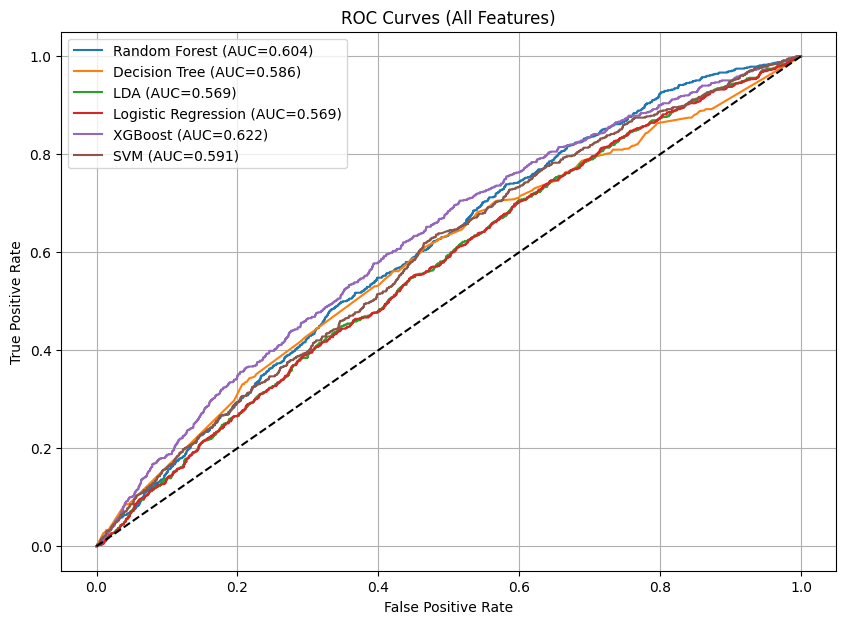

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

for name, model in models.items():
    model.fit(X_train_all_scaled, y_train_bal)
    y_prob = model.predict_proba(X_test_all_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (All Features)")
plt.legend()
plt.grid(True)
plt.show()



 CONFUSION MATRICES FOR: Random Forest


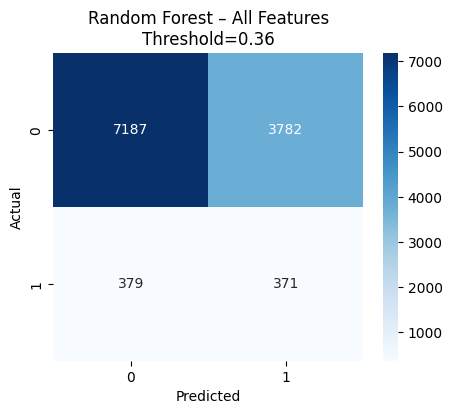

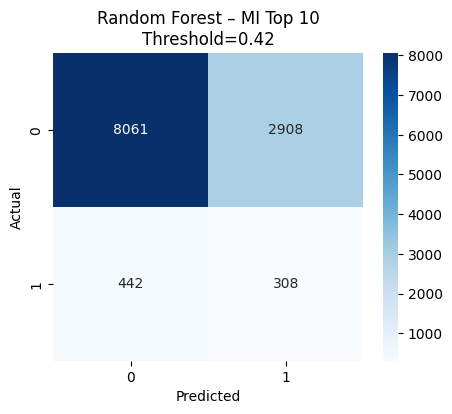

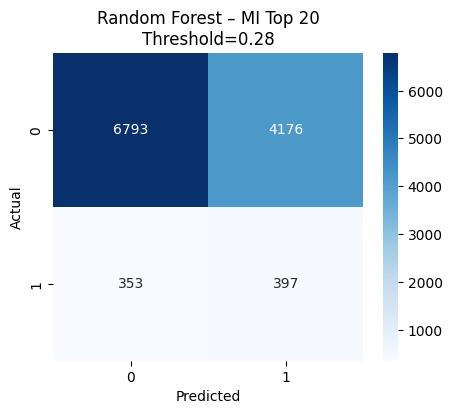


 CONFUSION MATRICES FOR: Decision Tree


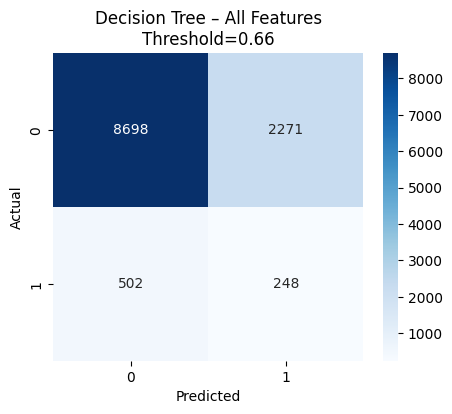

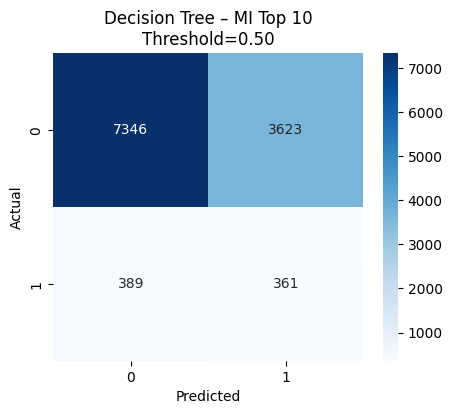

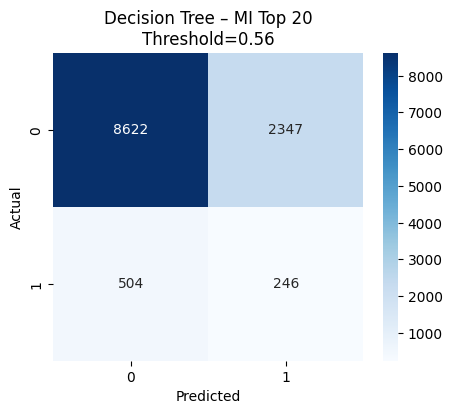


 CONFUSION MATRICES FOR: LDA


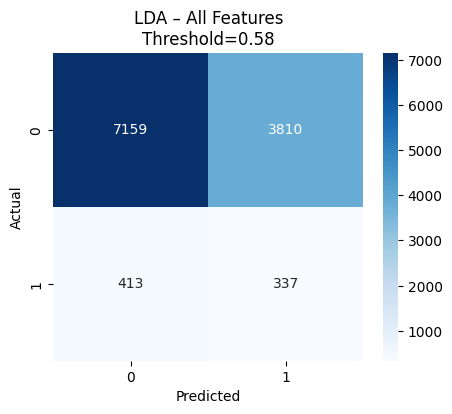

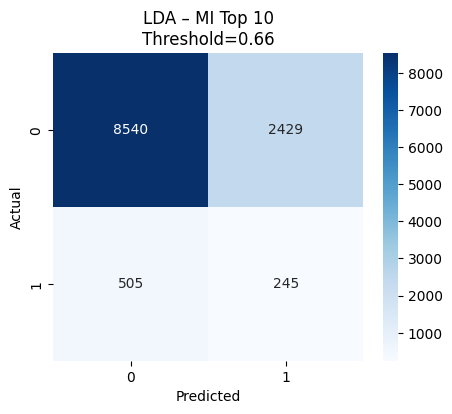

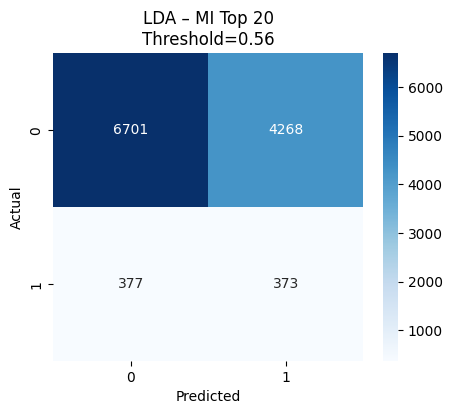


 CONFUSION MATRICES FOR: Logistic Regression


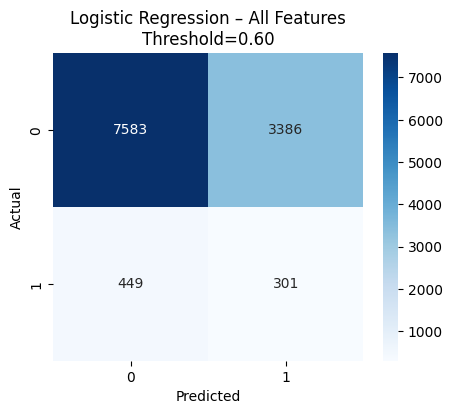

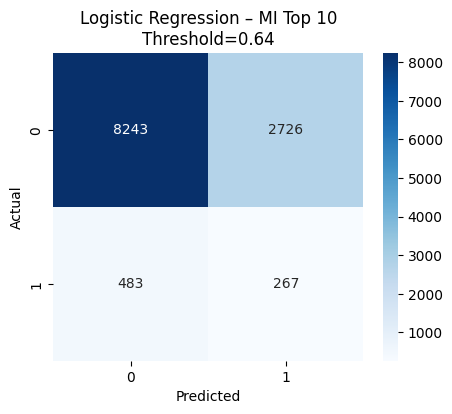

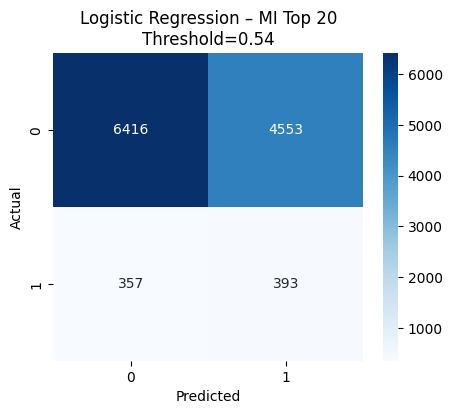


 CONFUSION MATRICES FOR: XGBoost


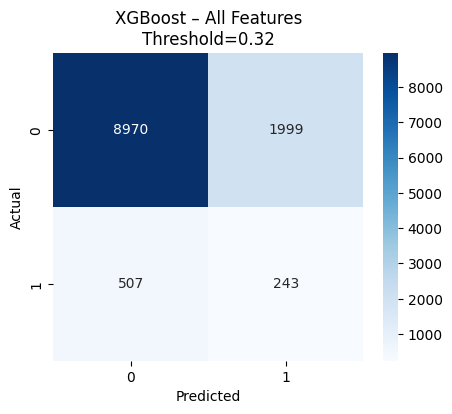

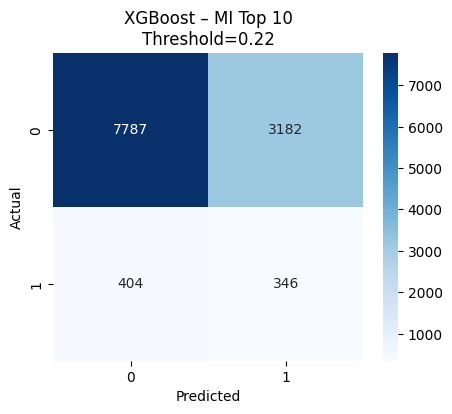

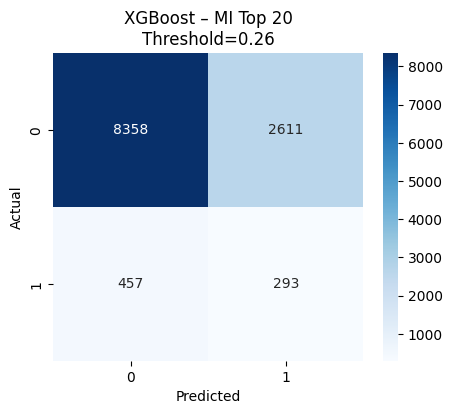


 CONFUSION MATRICES FOR: SVM


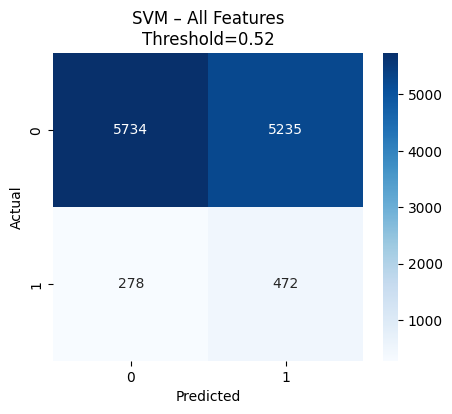

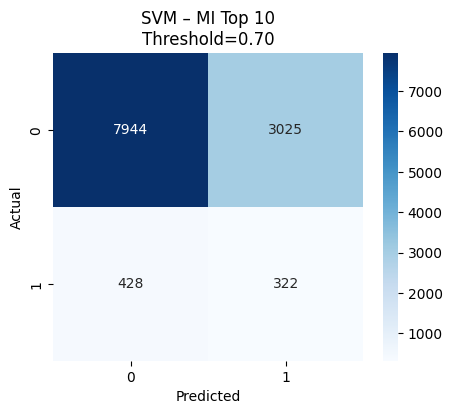

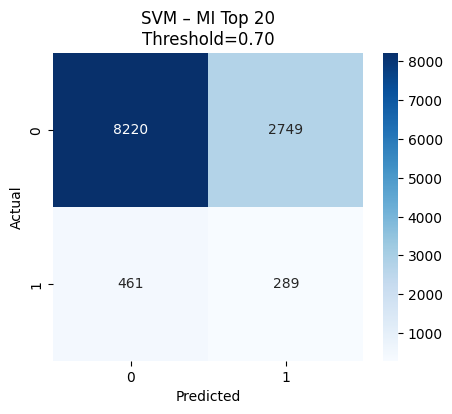

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------
# FUNCTION: Generate Confusion Matrix (No Retrain)
# ------------------------------------------------
def cm_no_retrain(model_name, model, X_test, subset):
    # Get best threshold from results table
    thr = df_results[(df_results["Model"] == model_name) &
                     (df_results["Subset"] == subset)]["Best Threshold"].iloc[0]

    # Predict probabilities WITHOUT retraining
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert using threshold
    y_pred = (y_prob >= thr).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot CM
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"{model_name} – {subset}\nThreshold={thr:.2f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ------------------------------------------------
# Feature subset test sets (already scaled)
# ------------------------------------------------
subset_map = {
    "All Features": X_test_all_scaled,
    "MI Top 10": X_test_mi10_scaled,
    "MI Top 20": X_test_mi20_scaled
}

# Define a map for X_train_scaled corresponding to each subset
train_subset_map = {
    "All Features": X_train_all_scaled,
    "MI Top 10": X_train_mi10_scaled,
    "MI Top 20": X_train_mi20_scaled
}

# ------------------------------------------------
# Generate Confusion Matrices for All Models
# ------------------------------------------------
for model_name, original_model_instance in models.items():
    print("\n======================================================")
    print(f" CONFUSION MATRICES FOR: {model_name}")
    print("======================================================")

    for subset, Xtest in subset_map.items():
        Xtrain_for_subset = train_subset_map[subset]

        # Create a fresh, untrained instance of the model based on its type
        # and the best parameters found (if applicable) for models that were GridSearchCV results
        # For others, we clone to get a fresh instance.
        temp_model = None
        if model_name == "Random Forest":
            # Create a new RF model with best params from grid search
            temp_model = RandomForestClassifier(
                n_estimators=best_rf.n_estimators,
                max_depth=best_rf.max_depth,
                class_weight=best_rf.class_weight,
                random_state=best_rf.random_state
            )
        elif model_name == "Decision Tree":
            # Create a new DT model with best params from grid search
            temp_model = DecisionTreeClassifier(
                max_depth=best_dt.max_depth,
                min_samples_split=best_dt.min_samples_split,
                class_weight=best_dt.class_weight,
                random_state=best_dt.random_state
            )
        elif model_name == "XGBoost":
            # Create a new XGBoost model with best params from grid search
            temp_model = XGBClassifier(
                learning_rate=best_xgb.learning_rate,
                max_depth=best_xgb.max_depth,
                n_estimators=best_xgb.n_estimators,
                eval_metric='logloss',
                random_state=best_xgb.random_state,
                tree_method="hist"
            )
        else:
            # For other models (LDA, Logistic Regression, SVM), clone the original instance
            # to ensure we start with an unfitted model for this subset.
            temp_model = clone(original_model_instance)
            # Ensure SVM has probability=True if cloned, as clone might not copy it
            if isinstance(temp_model, SVC):
                temp_model.probability = True

        # Fit this fresh instance on the specific training data for the current subset
        temp_model.fit(Xtrain_for_subset, y_train_bal)

        # Call cm_no_retrain with this newly trained model instance
        cm_no_retrain(model_name, temp_model, Xtest, subset)
